In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier, plot_importance

## 1. Carregando os Dados

In [2]:
df = pd.read_csv('../../data/processed/preprocessed_1.csv')

X = df.drop('classe', axis=1)
y = df['classe']

# O XGBoost EXIGE que as classes alvo sejam inteiros sequenciais começando de 0 (0, 1, 2, 3...)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Separando em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

## 2. Treinamento do Modelo XGBoost
Utilizamos hiperparâmetros básicos para evitar overfitting

In [3]:
xgb_model = XGBClassifier(
    n_estimators=100,      # Número de árvores sequenciais
    learning_rate=0.1,     # Passo de aprendizado (peso dado a cada nova árvore)
    max_depth=5,           # Profundidade máxima de cada árvore
    random_state=42,
    eval_metric='mlogloss' # Métrica de erro para classificação multiclasse
)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

## 3. Avaliação e Importância das Features
Verificamos as métricas de acerto. Além disso, o XGBoost nos permite extrair diretamente quais posições do tabuleiro foram matematicamente mais relevantes para as decisões do modelo.

Acurácia: 0.98125

Relatório de Classificação:

              precision    recall  f1-score   support

      Empate       0.67      0.29      0.40         7
    O venceu       1.00      1.00      1.00        63
    Tem jogo       0.96      0.99      0.98       125
    X venceu       1.00      1.00      1.00       125

    accuracy                           0.98       320
   macro avg       0.91      0.82      0.84       320
weighted avg       0.98      0.98      0.98       320



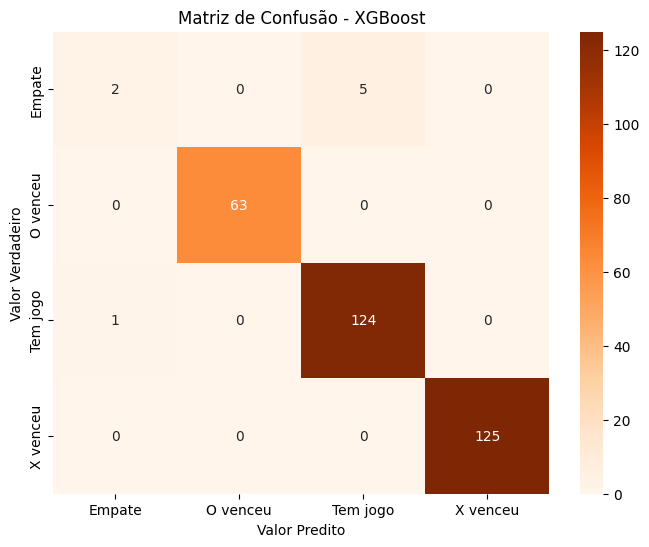

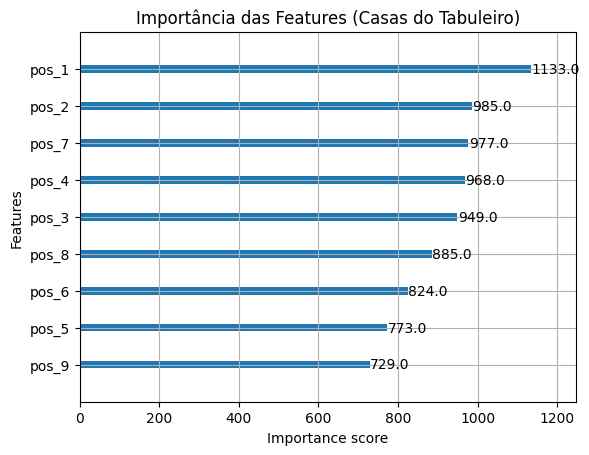

In [4]:
y_pred = xgb_model.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Plotando a matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão - XGBoost')
plt.ylabel('Valor Verdadeiro')
plt.xlabel('Valor Predito')
plt.show()

print("\n")
# Feature Importance (Quais casas do tabuleiro ditam o jogo?)
plot_importance(xgb_model, importance_type='weight', title="Importância das Features (Casas do Tabuleiro)")
plt.show()

In [5]:
os.makedirs('../../models/GradientBoost', exist_ok=True)

joblib.dump(xgb_model, '../../models/GradientBoost/xgboost_model.pkl')
joblib.dump(le, '../../models/GradientBoost/label_encoder_xgb.pkl')
print(f"Modelo salvo com sucesso em: {'../../models/GradientBoost'}")

Modelo salvo com sucesso em: ../../models/GradientBoost
